In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Name_data_BCM = "Learning_BCM"
time_BCM = "04:09"
date = datetime.datetime.now().strftime("%m-%d")
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_data_BCM = sio.loadmat('Data/'+date+'/Output_'+Name_data_BCM+'_'+time_BCM+'.mat', squeeze_me=True)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_data_BCM,Output_data_BCM,"")
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_data_BCM,Output_data_BCM,"_Coupled")
time_x_BCM = Noise_BCM.t

step1 = 1200
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

CPU times: user 4.21 s, sys: 6.92 s, total: 11.1 s
Wall time: 12.8 s


In [2]:
%%time
PC_new_learned_BCM = New_PC_learned(Params,PC_BCM)
PC_new_learned_Coupled_BCM = New_PC_learned(Params,PC_BCM)

CPU times: user 8.37 s, sys: 64.7 ms, total: 8.43 s
Wall time: 8.44 s


In [3]:
# def raster_plot(learned,step1,Params,IO,PC):
#     for ii in range(0,Params.N_Cells_PC):
#         plt.figure(figsize=(7, 5), dpi= 80, facecolor='w', edgecolor='k')
#         jj = Synapses.IO_PC_Synapse_Sources[ii]
#         if learned == "Learned":
#             PC_all = PC.Spikemon_Cells[ii][len(PC.Spikemon_Cells[ii])//2:]
#             IO_all = IO.Spikemon_Cells[jj][len(IO.Spikemon_Cells[jj])//2:]
#         else:
#             PC_all = PC.Spikemon_Cells[ii][:len(PC.Spikemon_Cells[ii])//2]
#             IO_all = IO.Spikemon_Cells[jj][:len(PC.Spikemon_Cells[ii])//2]
#         for kk in range(0,len(IO_all)):
#             start = IO_all[kk]-step1/1000
#             end = IO_all[kk]+step1/1000
#             if start<50:
#                 continue
#             bb = []
#             for ss in range(0,len(PC_all)):
#                 if start<=PC_all[ss]<=end:
#                     bb.append(PC_all[ss])
#                 else:
#                     continue
#             plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black')
#             aa = []
#             for ll in range(0,len(IO_all)):
#                 if start<=IO_all[ll]<=end:
#                     aa.append(IO_all[ll])
#                 else:
#                     continue
#             plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue')
#             plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red')
#         plt.show()



In [4]:
# raster_plot("",step1,Params,IO,PC)

In [5]:
# raster_plot("Learned",step1,Params,IO,PC)

In [27]:
IO_Coupled_BCM.Spikemon_Cells[jj][len(IO_Coupled_BCM.Spikemon_Cells[jj])//2:]

array([59.8171])

In [29]:
IO_Coupled_BCM.Spikemon_Cells[jj]

array([ 2.157725, 59.8171  ])

In [11]:
start

204.39577500000001

In [20]:
aa

[205.595775]

3
155.31905000000003 110.588125 157.71905
155.31905000000003 156.51905000000002 157.71905
155.31905000000003 205.595775 157.71905
3
204.39577500000001 110.588125 206.795775
204.39577500000001 156.51905000000002 206.795775
204.39577500000001 205.595775 206.795775


Text(0.5, 0, 'Time [s]')

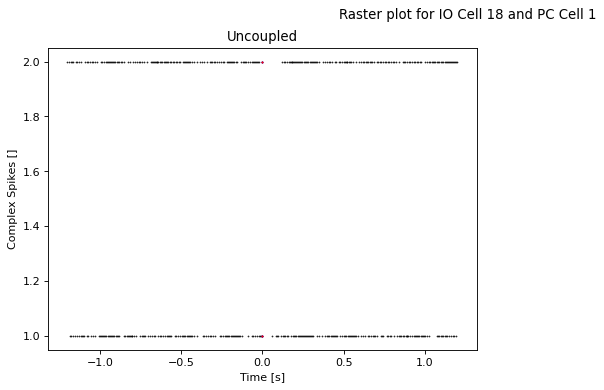

In [25]:
ii = 0
fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
gs1 = gridspec.GridSpec(1, 2)
gs1.update(wspace=0.025, hspace=0.05) # set the spacing between axes. 
jj = Synapses.IO_PC_Synapse_Sources[ii]
fig.suptitle('Raster plot for IO Cell '+str(jj+1)+' and PC Cell '+str(ii+1)) # or plt.suptitle('Main title')
if learned == "Learned":
    PC_all = PC_BCM.Spikemon_Cells[ii][len(PC_BCM.Spikemon_Cells[ii])//2:]
    if size(IO_BCM.Spikemon_Cells[jj]) < 2:
        IO_all = [IO_BCM.Spikemon_Cells[jj]]
    else:
        IO_all = IO_BCM.Spikemon_Cells[jj][len(IO_BCM.Spikemon_Cells[jj])//2:]
else:
    PC_all = PC_BCM.Spikemon_Cells[ii][:len(PC_BCM.Spikemon_Cells[ii])//2]
    if size(IO_BCM.Spikemon_Cells[jj]) < 2:
        IO_all = [IO_BCM.Spikemon_Cells[jj]]
    else:
        IO_all = IO_BCM.Spikemon_Cells[jj][:len(IO_BCM.Spikemon_Cells[ii])//2]
ax1 = plt.subplot(gs1[0])
for kk in range(0,size(IO_all)):
    start = IO_all[kk]-step1/1000
    end = IO_all[kk]+step1/1000
    if learned == "Learned":
        if start<int(Params.exp_run/second):
            continue
    else:
        if start>int(Params.exp_run/second):
            continue
    bb = []
    for ss in range(0,len(PC_all)):
        if start<=PC_all[ss]<=end:
            bb.append(PC_all[ss])
        else:
            continue
    ax1 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
    aa = []
    print(len(IO_all))
    for ll in range(0,len(IO_all)):
        print(start,IO_all[ll],end)
        if start<=IO_all[ll]<=end:
            aa.append(IO_all[ll])
        else:
            continue
    ax1 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
    ax1 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
plt.title('Uncoupled')
ylabel('Complex Spikes []')
xlabel('Time [s]')

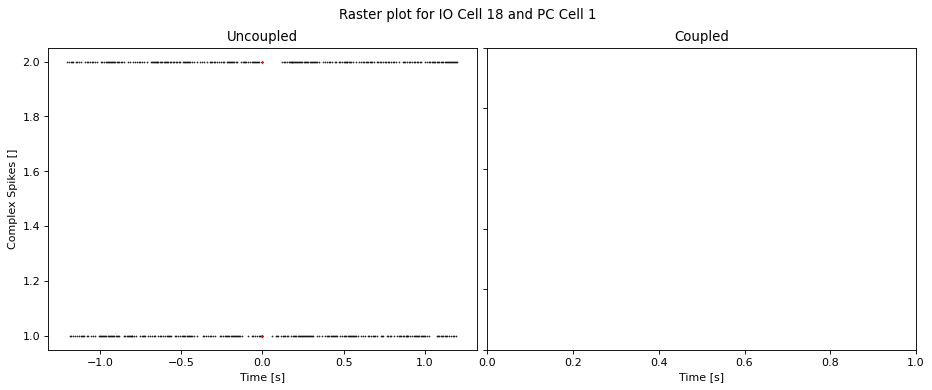

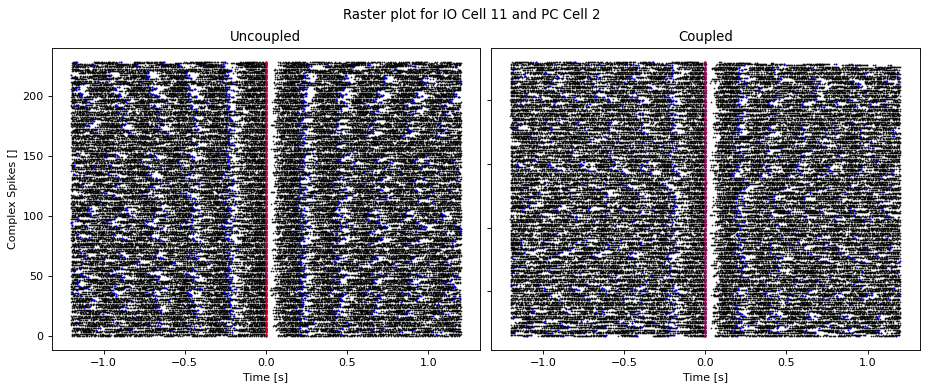

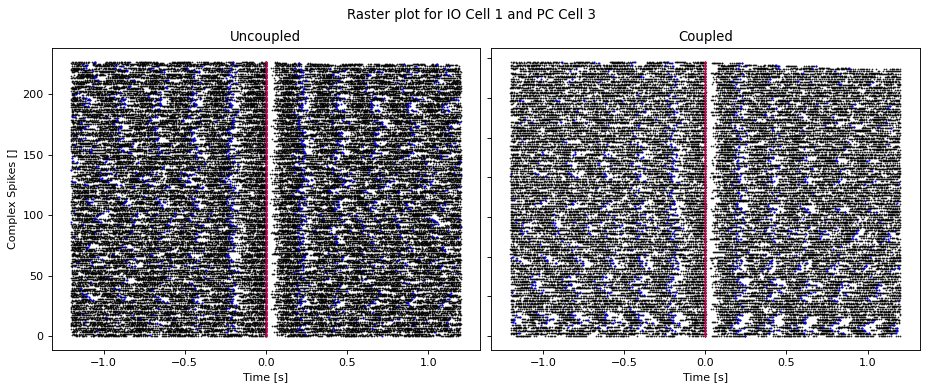

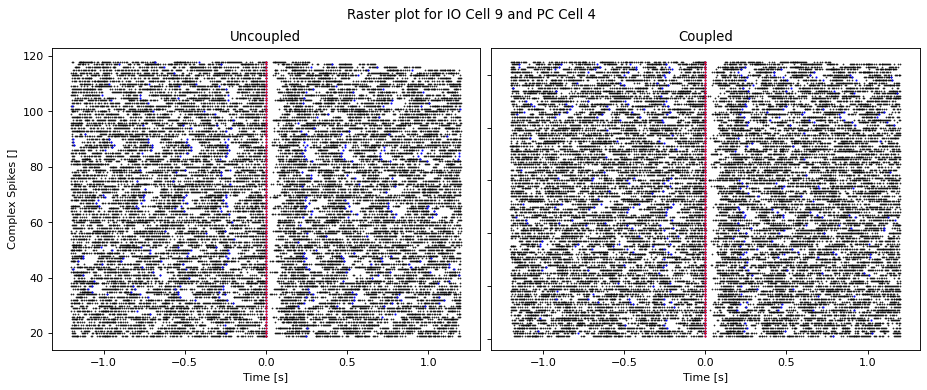

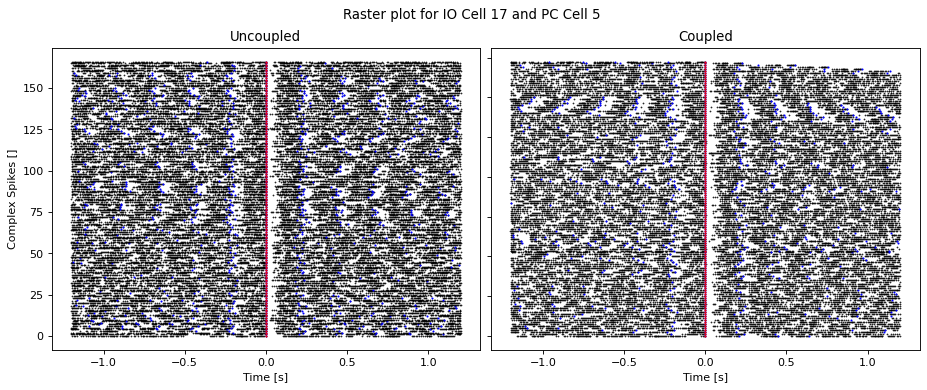

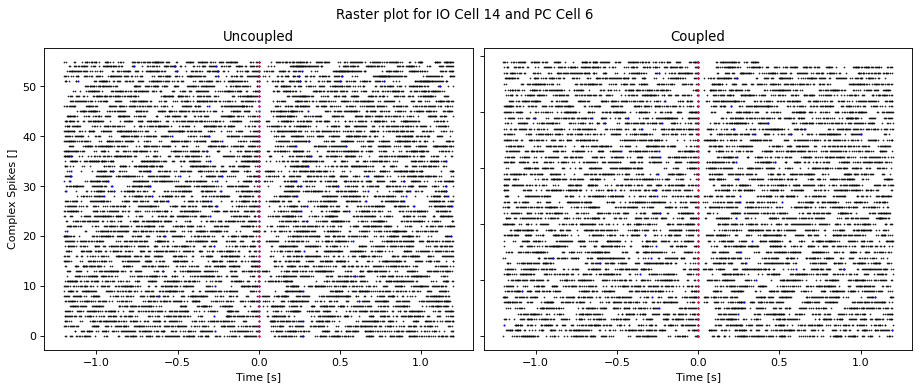

TypeError: object of type 'float' has no len()

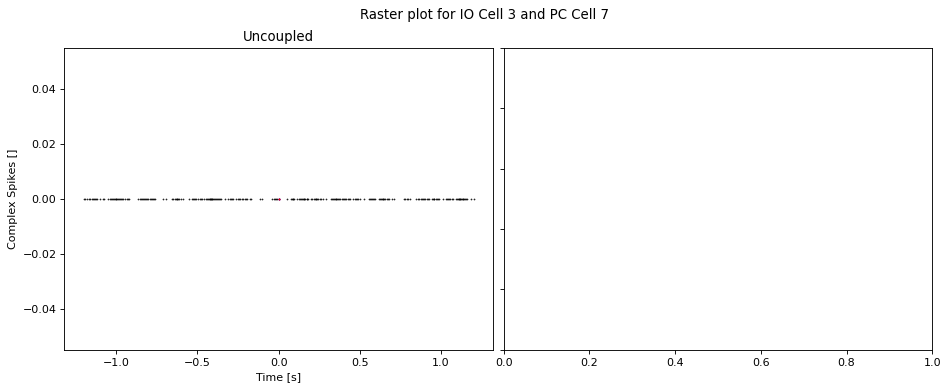

In [6]:
learned = "Learned"
for ii in range(0,Params.N_Cells_PC):
    fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    gs1 = gridspec.GridSpec(1, 2)
    gs1.update(wspace=0.025, hspace=0.05) # set the spacing between axes. 
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    fig.suptitle('Raster plot for IO Cell '+str(jj+1)+' and PC Cell '+str(ii+1)) # or plt.suptitle('Main title')
    if learned == "Learned":
        PC_all = PC_BCM.Spikemon_Cells[ii][len(PC_BCM.Spikemon_Cells[ii])//2:]
        if size(IO_BCM.Spikemon_Cells[jj]) < 2:
            IO_all = [IO_BCM.Spikemon_Cells[jj]]
        else:
            IO_all = IO_BCM.Spikemon_Cells[jj][len(IO_BCM.Spikemon_Cells[jj])//2:]
    else:
        PC_all = PC_BCM.Spikemon_Cells[ii][:len(PC_BCM.Spikemon_Cells[ii])//2]
        if size(IO_BCM.Spikemon_Cells[jj]) < 2:
            IO_all = [IO_BCM.Spikemon_Cells[jj]]
        else:
            IO_all = IO_BCM.Spikemon_Cells[jj][:len(IO_BCM.Spikemon_Cells[ii])//2]
    ax1 = plt.subplot(gs1[0])
    for kk in range(0,size(IO_all)):
        start = IO_all[kk]-step1/1000
        end = IO_all[kk]+step1/1000
        if learned == "Learned":
            if start<int(Params.exp_run/second):
                continue
        else:
            if start>int(Params.exp_run/second):
                continue
        bb = []
        for ss in range(0,len(PC_all)):
            if start<=PC_all[ss]<=end:
                bb.append(PC_all[ss])
            else:
                continue
        ax1 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
        aa = []
        for ll in range(0,len(IO_all)):
            if start<=IO_all[ll]<=end:
                aa.append(IO_all[ll])
            else:
                continue
        ax1 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
        ax1 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
    plt.title('Uncoupled')
    ylabel('Complex Spikes []')
    xlabel('Time [s]')
    ax2 = plt.subplot(gs1[1])
    ax2.set_yticklabels([])
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    if learned == "Learned":
        PC_all = PC_Coupled_BCM.Spikemon_Cells[ii][len(PC_Coupled_BCM.Spikemon_Cells[ii])//2:]
        if size(IO_BCM.Spikemon_Cells[jj]) < 2:
            IO_all = [IO_Coupled_BCM.Spikemon_Cells[jj]]
        else:
            IO_all = IO_Coupled_BCM.Spikemon_Cells[jj][len(IO_Coupled_BCM.Spikemon_Cells[jj])//2:]
    else:
        PC_all = PC_Coupled_BCM.Spikemon_Cells[ii][:len(PC_Coupled_BCM.Spikemon_Cells[jj])//2]
        if size(IO_BCM.Spikemon_Cells[jj]) < 2:
            IO_all = [IO_Coupled_BCM.Spikemon_Cells[jj]]
        else:
            IO_all = IO_Coupled_BCM.Spikemon_Cells[jj][:len(IO_Coupled_BCM.Spikemon_Cells[jj])//2]
    for kk in range(0,size(IO_all)):
        start = IO_all[kk]-step1/1000
        end = IO_all[kk]+step1/1000
        if learned == "Learned":
            if start<int(Params.exp_run/second):
                continue
        else:
            if start>int(Params.exp_run/second):
                continue
        bb = []
        for ss in range(0,len(PC_all)):
            if start<=PC_all[ss]<=end:
                bb.append(PC_all[ss])
            else:
                continue
        ax2 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
        aa = []
        for ll in range(0,len(IO_all)):
            if start<=IO_all[ll]<=end:
                aa.append(IO_all[ll])
            else:
                continue
        ax2 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
        ax2 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
    plt.title('Coupled')
    xlabel('Time [s]')   
    plt.show()

In [ ]:
learned = "Learned"
for ii in range(0,Params.N_Cells_PC):
    fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    gs1 = gridspec.GridSpec(1, 2)
    gs1.update(wspace=0.025, hspace=0.05) # set the spacing between axes. 
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    fig.suptitle('Raster plot for IO Cell '+str(jj+1)+' and PC Cell '+str(ii+1)) # or plt.suptitle('Main title')
    if learned == "Learned":
        PC_all = PC_BCM.Spikemon_Cells[ii][len(PC_BCM.Spikemon_Cells[ii])//2:]
        IO_all = IO_BCM.Spikemon_Cells[jj][len(IO_BCM.Spikemon_Cells[jj])//2:]

    else:
        PC_all = PC_BCM.Spikemon_Cells[ii][:len(PC_BCM.Spikemon_Cells[ii])//2]
        IO_all = IO_BCM.Spikemon_Cells[jj][:len(IO_BCM.Spikemon_Cells[ii])//2]
    if size(IO_all) < 2:
        IO_all = [IO_all]
    ax1 = plt.subplot(gs1[0])
    for kk in range(0,size(IO_all)):
        start = IO_all[kk]-step1/1000
        end = IO_all[kk]+step1/1000
        if learned == "Learned":
            if start<int(Params.exp_run/second):
                continue
        else:
            if start>int(Params.exp_run/second):
                continue
        bb = []
        for ss in range(0,len(PC_all)):
            if start<=PC_all[ss]<=end:
                bb.append(PC_all[ss])
            else:
                continue
        ax1 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
        aa = []
        for ll in range(0,len(IO_all)):
            if start<=IO_all[ll]<=end:
                aa.append(IO_all[ll])
            else:
                continue
        ax1 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
        ax1 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
    plt.title('Uncoupled')
    ylabel('Complex Spikes []')
    xlabel('Time [s]')
    ax2 = plt.subplot(gs1[1])
    ax2.set_yticklabels([])
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    if learned == "Learned":
        PC_all = PC_Coupled_BCM.Spikemon_Cells[ii][len(PC_Coupled_BCM.Spikemon_Cells[ii])//2:]
        IO_all = IO_Coupled_BCM.Spikemon_Cells[jj][len(IO_Coupled_BCM.Spikemon_Cells[jj])//2:]
    else:
        PC_all = PC_Coupled_BCM.Spikemon_Cells[ii][:len(PC_Coupled_BCM.Spikemon_Cells[jj])//2]
        IO_all = IO_Coupled_BCM.Spikemon_Cells[jj][:len(IO_Coupled_BCM.Spikemon_Cells[jj])//2]
    if size(IO_all) < 2:
        IO_all = [IO_all]
    for kk in range(0,size(IO_all)):
        start = IO_all[kk]-step1/1000
        end = IO_all[kk]+step1/1000
        if learned == "Learned":
            if start<int(Params.exp_run/second):
                continue
        else:
            if start>int(Params.exp_run/second):
                continue
        bb = []
        for ss in range(0,len(PC_all)):
            if start<=PC_all[ss]<=end:
                bb.append(PC_all[ss])
            else:
                continue
        ax2 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
        aa = []
        for ll in range(0,len(IO_all)):
            if start<=IO_all[ll]<=end:
                aa.append(IO_all[ll])
            else:
                continue
        ax2 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
        ax2 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
    plt.title('Coupled')
    xlabel('Time [s]')   
    plt.show()

In [ ]:
learned = "Learned"
ii = 0
fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
gs1 = gridspec.GridSpec(1, 2)
gs1.update(wspace=0.025, hspace=0.05) # set the spacing between axes. 
jj = Synapses.IO_PC_Synapse_Sources[ii]
fig.suptitle('Raster plot for IO Cell '+str(jj+1)+' and PC Cell '+str(ii+1)) # or plt.suptitle('Main title')
if learned == "Learned":
    PC_all = PC.Spikemon_Cells[ii][len(PC.Spikemon_Cells[ii])//2:]
    IO_all = IO.Spikemon_Cells[jj][len(IO.Spikemon_Cells[jj])//2:]
    if size(IO.Spikemon_Cells[jj][len(IO.Spikemon_Cells[jj])//2:]) < 2:
        IO_all = [IO.Spikemon_Cells[jj][len(IO.Spikemon_Cells[jj])//2:]]
else:
    PC_all = PC.Spikemon_Cells[ii][:len(PC.Spikemon_Cells[ii])//2]
    if size(IO.Spikemon_Cells[jj][:len(IO.Spikemon_Cells[ii])//2]) < 2:
        IO_all = [IO.Spikemon_Cells[jj][:len(IO.Spikemon_Cells[ii])//2]]
    else: 
        IO_all = IO.Spikemon_Cells[jj][:len(IO.Spikemon_Cells[ii])//2]
ax1 = plt.subplot(gs1[0])
for kk in range(0,len(IO_all)):
    start = IO_all[kk]-step1/1000
    end = IO_all[kk]+step1/1000
    if learned == "Learned":
        if start<int(Params.exp_run/second):
            continue
    else:
        if start>int(Params.exp_run/second):
            continue
    bb = []
    for ss in range(0,len(PC_all)):
        if start<=PC_all[ss]<=end:
            bb.append(PC_all[ss])
        else:
            continue
    ax1 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
    aa = []
    for ll in range(0,len(IO_all)):
        if start<=IO_all[ll]<=end:
            aa.append(IO_all[ll])
        else:
            continue
    ax1 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
    ax1 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
plt.title('Uncoupled')
ylabel('Complex Spikes []')
xlabel('Time [s]')
ax2 = plt.subplot(gs1[1])
ax2.set_yticklabels([])
jj = Synapses.IO_PC_Synapse_Sources[ii]
if learned == "Learned":
    PC_all = PC_Coupled.Spikemon_Cells[ii][len(PC.Spikemon_Cells[ii])//2:]
    if size(IO_Coupled.Spikemon_Cells[jj]) < 2:
        IO_all = [IO_Coupled.Spikemon_Cells[jj]]
    else:
        IO_all = IO_Coupled.Spikemon_Cells[jj][len(IO_Coupled.Spikemon_Cells[jj])//2:]
else:
    PC_all = PC_Coupled.Spikemon_Cells[ii][:len(PC_Coupled.Spikemon_Cells[jj])//2]
    if size(IO_Coupled.Spikemon_Cells[jj][:len(IO_Coupled.Spikemon_Cells[jj])//2]) < 2:
        IO_all = [IO_Coupled.Spikemon_Cells[jj][:len(IO_Coupled.Spikemon_Cells[jj])//2]]
    else:
        IO_all = IO_Coupled.Spikemon_Cells[jj][:len(IO_Coupled.Spikemon_Cells[jj])//2]
for kk in range(0,len(IO_all)):
    start = IO_all[kk]-step1/1000
    end = IO_all[kk]+step1/1000
    print(start,end)
    print(IO_all)
    if learned == "Learned":
        if start<int(Params.exp_run/second):
            continue
    else:
        if start>int(Params.exp_run/second):
            continue
    bb = []
    for ss in range(0,len(PC_all)):
        if start<=PC_all[ss]<=end:
            bb.append(PC_all[ss])
        else:
            continue
    ax2 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
    aa = []
    for ll in range(0,len(IO_all)):
        if start<=IO_all[ll]<=end:
            aa.append(IO_all[ll])
        else:
            continue
    ax2 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
    ax2 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
plt.title('Coupled')
xlabel('Time [s]')   
plt.show()